In [1]:
# !pip install timm pydicom pandas opencv-python-headless scikit-learn seaborn

import os
import cv2
import pydicom
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import timm 
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve, multilabel_confusion_matrix

# ==========================================
# CONFIGURATION
# ==========================================
class Config:
    # --- PATHS (Update these!) ---
    BASE_PATH = "/kaggle/input/rsna-intracranial-aneurysm-detection"
    CSV_PATH = os.path.join(BASE_PATH, "train.csv")
    IMAGE_DIR = os.path.join(BASE_PATH, "series")
    
    # --- LABELS (Multi-Label Task) ---
    LABEL_COLS = [
        'Left Infraclinoid Internal Carotid Artery',
        'Right Infraclinoid Internal Carotid Artery',
        'Left Supraclinoid Internal Carotid Artery',
        'Right Supraclinoid Internal Carotid Artery',
        'Left Middle Cerebral Artery',
        'Right Middle Cerebral Artery',
        'Anterior Communicating Artery',
        'Left Anterior Cerebral Artery',
        'Right Anterior Cerebral Artery',
        'Left Posterior Communicating Artery',
        'Right Posterior Communicating Artery',
        'Basilar Tip',
        'Other Posterior Circulation',
        'Aneurysm Present'
    ]
    
    # --- MODEL & TRAINING ---
    # Swin Tiny: Excellent trade-off for medical imaging features
    MODEL_NAME = 'swin_tiny_patch4_window7_224' 
    IMG_SIZE = (224, 224)   # Swin requires 224x224
    BATCH_SIZE = 16         # Adjust based on GPU VRAM (Try 8 if OOM)
    EPOCHS = 10
    LR = 5e-5               # Transformers need lower LR than CNNs
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    
    # --- SAVING ---
    SAVE_PATH = "best_rsna_swin_model.pth"

print(f"✅ Configuration Loaded. Using Device: {Config.DEVICE}")

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

✅ Configuration Loaded. Using Device: cuda


In [2]:
class DataRetriever:
    """Helper to load, window, and resize DICOMs"""
    
    @staticmethod
    def load_dicom(path):
        try:
            ds = pydicom.dcmread(path, stop_before_pixels=False)
            img = ds.pixel_array.astype(np.float32)
            
            # 1. Standard Angio Windowing (Center=100, Width=200)
            center, width = 100, 200
            if hasattr(ds, 'WindowCenter') and hasattr(ds, 'WindowWidth'):
                c = ds.WindowCenter if not isinstance(ds.WindowCenter, pydicom.multival.MultiValue) else ds.WindowCenter[0]
                w = ds.WindowWidth if not isinstance(ds.WindowWidth, pydicom.multival.MultiValue) else ds.WindowWidth[0]
                center, width = float(c), float(w)
            
            lower = center - width / 2
            upper = center + width / 2
            img = np.clip(img, lower, upper)
            
            # 2. Normalize 0-1
            img = (img - lower) / (upper - lower)
            
            # 3. Resize to Swin Spec
            img = cv2.resize(img, Config.IMG_SIZE, interpolation=cv2.INTER_AREA)
            return img
        except:
            return np.zeros(Config.IMG_SIZE, dtype=np.float32)

    @staticmethod
    def get_sorted_files(series_uid):
        """Returns DICOM paths sorted by Z-position (Instance Number)"""
        series_path = os.path.join(Config.IMAGE_DIR, str(series_uid))
        if not os.path.exists(series_path): return []
        
        files = []
        for f in os.listdir(series_path):
            if f.endswith('.dcm'):
                p = os.path.join(series_path, f)
                try:
                    # Read header only for speed
                    d = pydicom.dcmread(p, stop_before_pixels=True)
                    files.append((int(d.InstanceNumber), p))
                except: continue
        
        files.sort(key=lambda x: x[0])
        return [f[1] for f in files]

from joblib import Parallel, delayed

# Helper function needs to be outside class for Parallel pickling
def process_single_series(row, image_dir, deltas, label_cols):
    sid = row['SeriesInstanceUID']
    labels = row[label_cols].values.astype(np.float32)
    
    # 1. Get files (IO Bound - this benefits from parallelism)
    series_path = os.path.join(image_dir, str(sid))
    if not os.path.exists(series_path): return []
    
    files = []
    try:
        # Fast directory scan
        dir_files = [f for f in os.listdir(series_path) if f.endswith('.dcm')]
        for f in dir_files:
            p = os.path.join(series_path, f)
            # Read header only
            d = pydicom.dcmread(p, stop_before_pixels=True)
            files.append((int(d.InstanceNumber), p))
    except:
        return []
        
    if len(files) < 3: return []
    
    # Sort by Z-axis
    files.sort(key=lambda x: x[0])
    paths = [f[1] for f in files]
    n_slices = len(paths)
    
    # 2. Smart Sampling Logic
    samples = []
    if row['Aneurysm Present'] == 1:
        # Positive: Take 5 evenly spaced slices
        indices = np.linspace(0, n_slices - 1, num=5).astype(int)
        indices = np.unique(indices)
    else:
        # Negative: Take center slice
        indices = [n_slices // 2]

    for c_idx in indices:
        samples.append({
            'paths': paths, 
            'center_idx': c_idx, 
            'labels': labels
        })
    return samples

class RSNAViTDataset(Dataset):
    def __init__(self, df, deltas=(-1, 0, 1)):
        self.df = df
        self.deltas = deltas
        
        print(f"Indexing {len(df)} Series using 4 CPU Cores...")
        
        # Parallel Execution
        # n_jobs=4 uses all Kaggle CPU cores
        results = Parallel(n_jobs=4, backend="threading")(
            delayed(process_single_series)(
                row, Config.IMAGE_DIR, deltas, Config.LABEL_COLS
            ) for _, row in tqdm(df.iterrows(), total=len(df))
        )
        
        # Flatten the list of lists
        self.samples = [item for sublist in results for item in sublist]
        print(f"Indexing Complete. Total Training Samples: {len(self.samples)}")

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]
        paths = item['paths']
        c = item['center_idx']
        
        # Load images on the fly (still single threaded here, which is fine for DataLoader)
        imgs = []
        for d in self.deltas:
            k = np.clip(c + d, 0, len(paths) - 1)
            imgs.append(DataRetriever.load_dicom(paths[k]))
            
        stack = np.stack(imgs, axis=0)
        return torch.tensor(stack, dtype=torch.float32), torch.tensor(item['labels'], dtype=torch.float32)

In [3]:
class RSNAViT(nn.Module):
    def __init__(self, num_classes, model_name=Config.MODEL_NAME):
        super().__init__()
        # Load Swin Transformer
        # in_chans=3 allows it to read our 2.5D stack
        self.backbone = timm.create_model(model_name, pretrained=True, in_chans=3, num_classes=0)
        
        # Dynamic feature dimension check
        if hasattr(self.backbone, 'num_features'):
            n_inputs = self.backbone.num_features
        else:
            n_inputs = self.backbone.embed_dim
            
        # Custom Head for Multi-Label
        self.head = nn.Sequential(
            nn.LayerNorm(n_inputs),
            nn.Dropout(0.3),
            nn.Linear(n_inputs, num_classes)
        )
        
    def forward(self, x):
        return self.head(self.backbone(x))

In [4]:
def train_pipeline():
    # 1. Load & Split Data
    if not os.path.exists(Config.CSV_PATH):
        print("❌ CSV Path not found. check Config.")
        return None, None

    full_df = pd.read_csv(Config.CSV_PATH)
    
    # Check for duplicates to prevent data leakage
    full_df = full_df.drop_duplicates(subset=['SeriesInstanceUID'])
    
    train_df = full_df.sample(frac=0.8, random_state=42)
    val_df = full_df.drop(train_df.index)
    
    print(f"Train Series: {len(train_df)} | Val Series: {len(val_df)}")
    
    # Note: RSNAViTDataset here MUST be the 'Smart Sampling' version from Cell 2
    train_loader = DataLoader(RSNAViTDataset(train_df), batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(RSNAViTDataset(val_df), batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=2)
    
    # 2. Init Model
    model = RSNAViT(num_classes=len(Config.LABEL_COLS)).to(Config.DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=Config.LR, weight_decay=1e-2)
    scheduler = CosineAnnealingLR(optimizer, T_max=Config.EPOCHS)
    
    # ====================================================
    # !!! CONFIGURATION FOR SMART SAMPLING !!!
    # ====================================================
    # Since we are now physically oversampling positive slices by ~5x in the Dataset,
    # we reduce the mathematical weight from 20.0 to 5.0 to avoid false positives.
    pos_weight = torch.tensor([5.0] * len(Config.LABEL_COLS)).to(Config.DEVICE)
    
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight) 
    # ====================================================
    
    # 3. Training Loop
    best_loss = float('inf')
    
    for epoch in range(Config.EPOCHS):
        print(f"\nEpoch {epoch+1}/{Config.EPOCHS}")
        
        # --- Train ---
        model.train()
        train_loss = 0
        for x, y in tqdm(train_loader, desc="Training"):
            x, y = x.to(Config.DEVICE), y.to(Config.DEVICE)
            
            optimizer.zero_grad()
            # Mixed Precision is handled automatically by P100/New PyTorch, 
            # but standard FP32 is fine given your batch size.
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            
        scheduler.step()
        
        # --- Validate ---
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x, y in tqdm(val_loader, desc="Validating"):
                x, y = x.to(Config.DEVICE), y.to(Config.DEVICE)
                val_loss += criterion(model(x), y).item()
                
        avg_val = val_loss / len(val_loader)
        print(f"Val Loss: {avg_val:.4f}")
        
        # --- Save Best ---
        if avg_val < best_loss:
            best_loss = avg_val
            checkpoint = {
                'state_dict': model.state_dict(),
                'labels': Config.LABEL_COLS,
                'config': {
                    'model_name': Config.MODEL_NAME,
                    'img_size': Config.IMG_SIZE
                },
                'best_val_loss': best_loss
            }
            torch.save(checkpoint, Config.SAVE_PATH)
            print(f"✅ Best Model Saved! (Loss: {best_loss:.4f})")

    return model, val_loader

# RUN TRAINING
model, val_loader = train_pipeline()

Train Series: 3478 | Val Series: 870
Indexing 3478 Series using 4 CPU Cores...


100%|██████████| 3478/3478 [31:03<00:00,  1.87it/s]


Indexing Complete. Total Training Samples: 8705
Indexing 870 Series using 4 CPU Cores...


100%|██████████| 870/870 [08:22<00:00,  1.73it/s]


Indexing Complete. Total Training Samples: 2205


...

Val Loss: 0.9542

Epoch 9/10


Training:   0%|          | 2/545 [00:01<04:01,  2.25it/s]/usr/local/lib/python3.11/dist-packages/pydicom/pixels/utils.py:222: UserWarning: A value of 'None' for (0028,0008) 'Number of Frames' is invalid, assuming 1 frame
  warn_and_log(
Training:  32%|███▏      | 175/545 [01:06<02:00,  3.06it/s]/usr/local/lib/python3.11/dist-packages/pydicom/pixels/utils.py:222: UserWarning: A value of 'None' for (0028,0008) 'Number of Frames' is invalid, assuming 1 frame
  warn_and_log(
Validating: 100%|██████████| 138/138 [00:47<00:00,  2.94it/s]


Val Loss: 0.9946

Epoch 10/10


Training:  14%|█▎        | 74/545 [00:28<02:31,  3.11it/s]/usr/local/lib/python3.11/dist-packages/pydicom/pixels/utils.py:222: UserWarning: A value of 'None' for (0028,0008) 'Number of Frames' is invalid, assuming 1 frame
  warn_and_log(
Validating: 100%|██████████| 138/138 [00:47<00:00,  2.90it/s]

Val Loss: 1.0125


Inference: 100%|██████████| 138/138 [00:47<00:00,  2.93it/s]


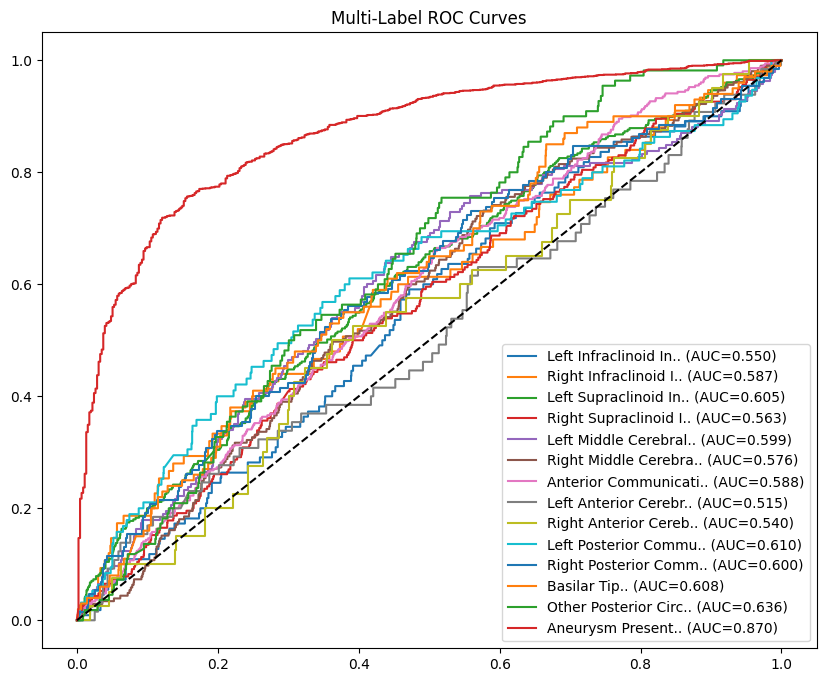

In [5]:
def plot_roc(model, loader):
    model.eval()
    y_true, y_probs = [], []
    
    with torch.no_grad():
        for x, y in tqdm(loader, desc="Inference"):
            logits = model(x.to(Config.DEVICE))
            y_true.append(y.cpu().numpy())
            y_probs.append(torch.sigmoid(logits).cpu().numpy())
            
    y_true = np.concatenate(y_true)
    y_probs = np.concatenate(y_probs)
    
    plt.figure(figsize=(10, 8))
    for i, label in enumerate(Config.LABEL_COLS):
        try:
            auc = roc_auc_score(y_true[:, i], y_probs[:, i])
            fpr, tpr, _ = roc_curve(y_true[:, i], y_probs[:, i])
            plt.plot(fpr, tpr, label=f"{label[:20]}.. (AUC={auc:.3f})")
        except: pass
        
    plt.plot([0,1],[0,1],'k--')
    plt.legend(loc='lower right')
    plt.title("Multi-Label ROC Curves")
    plt.show()

if model: plot_roc(model, val_loader)

100%|██████████| 138/138 [00:48<00:00,  2.86it/s]


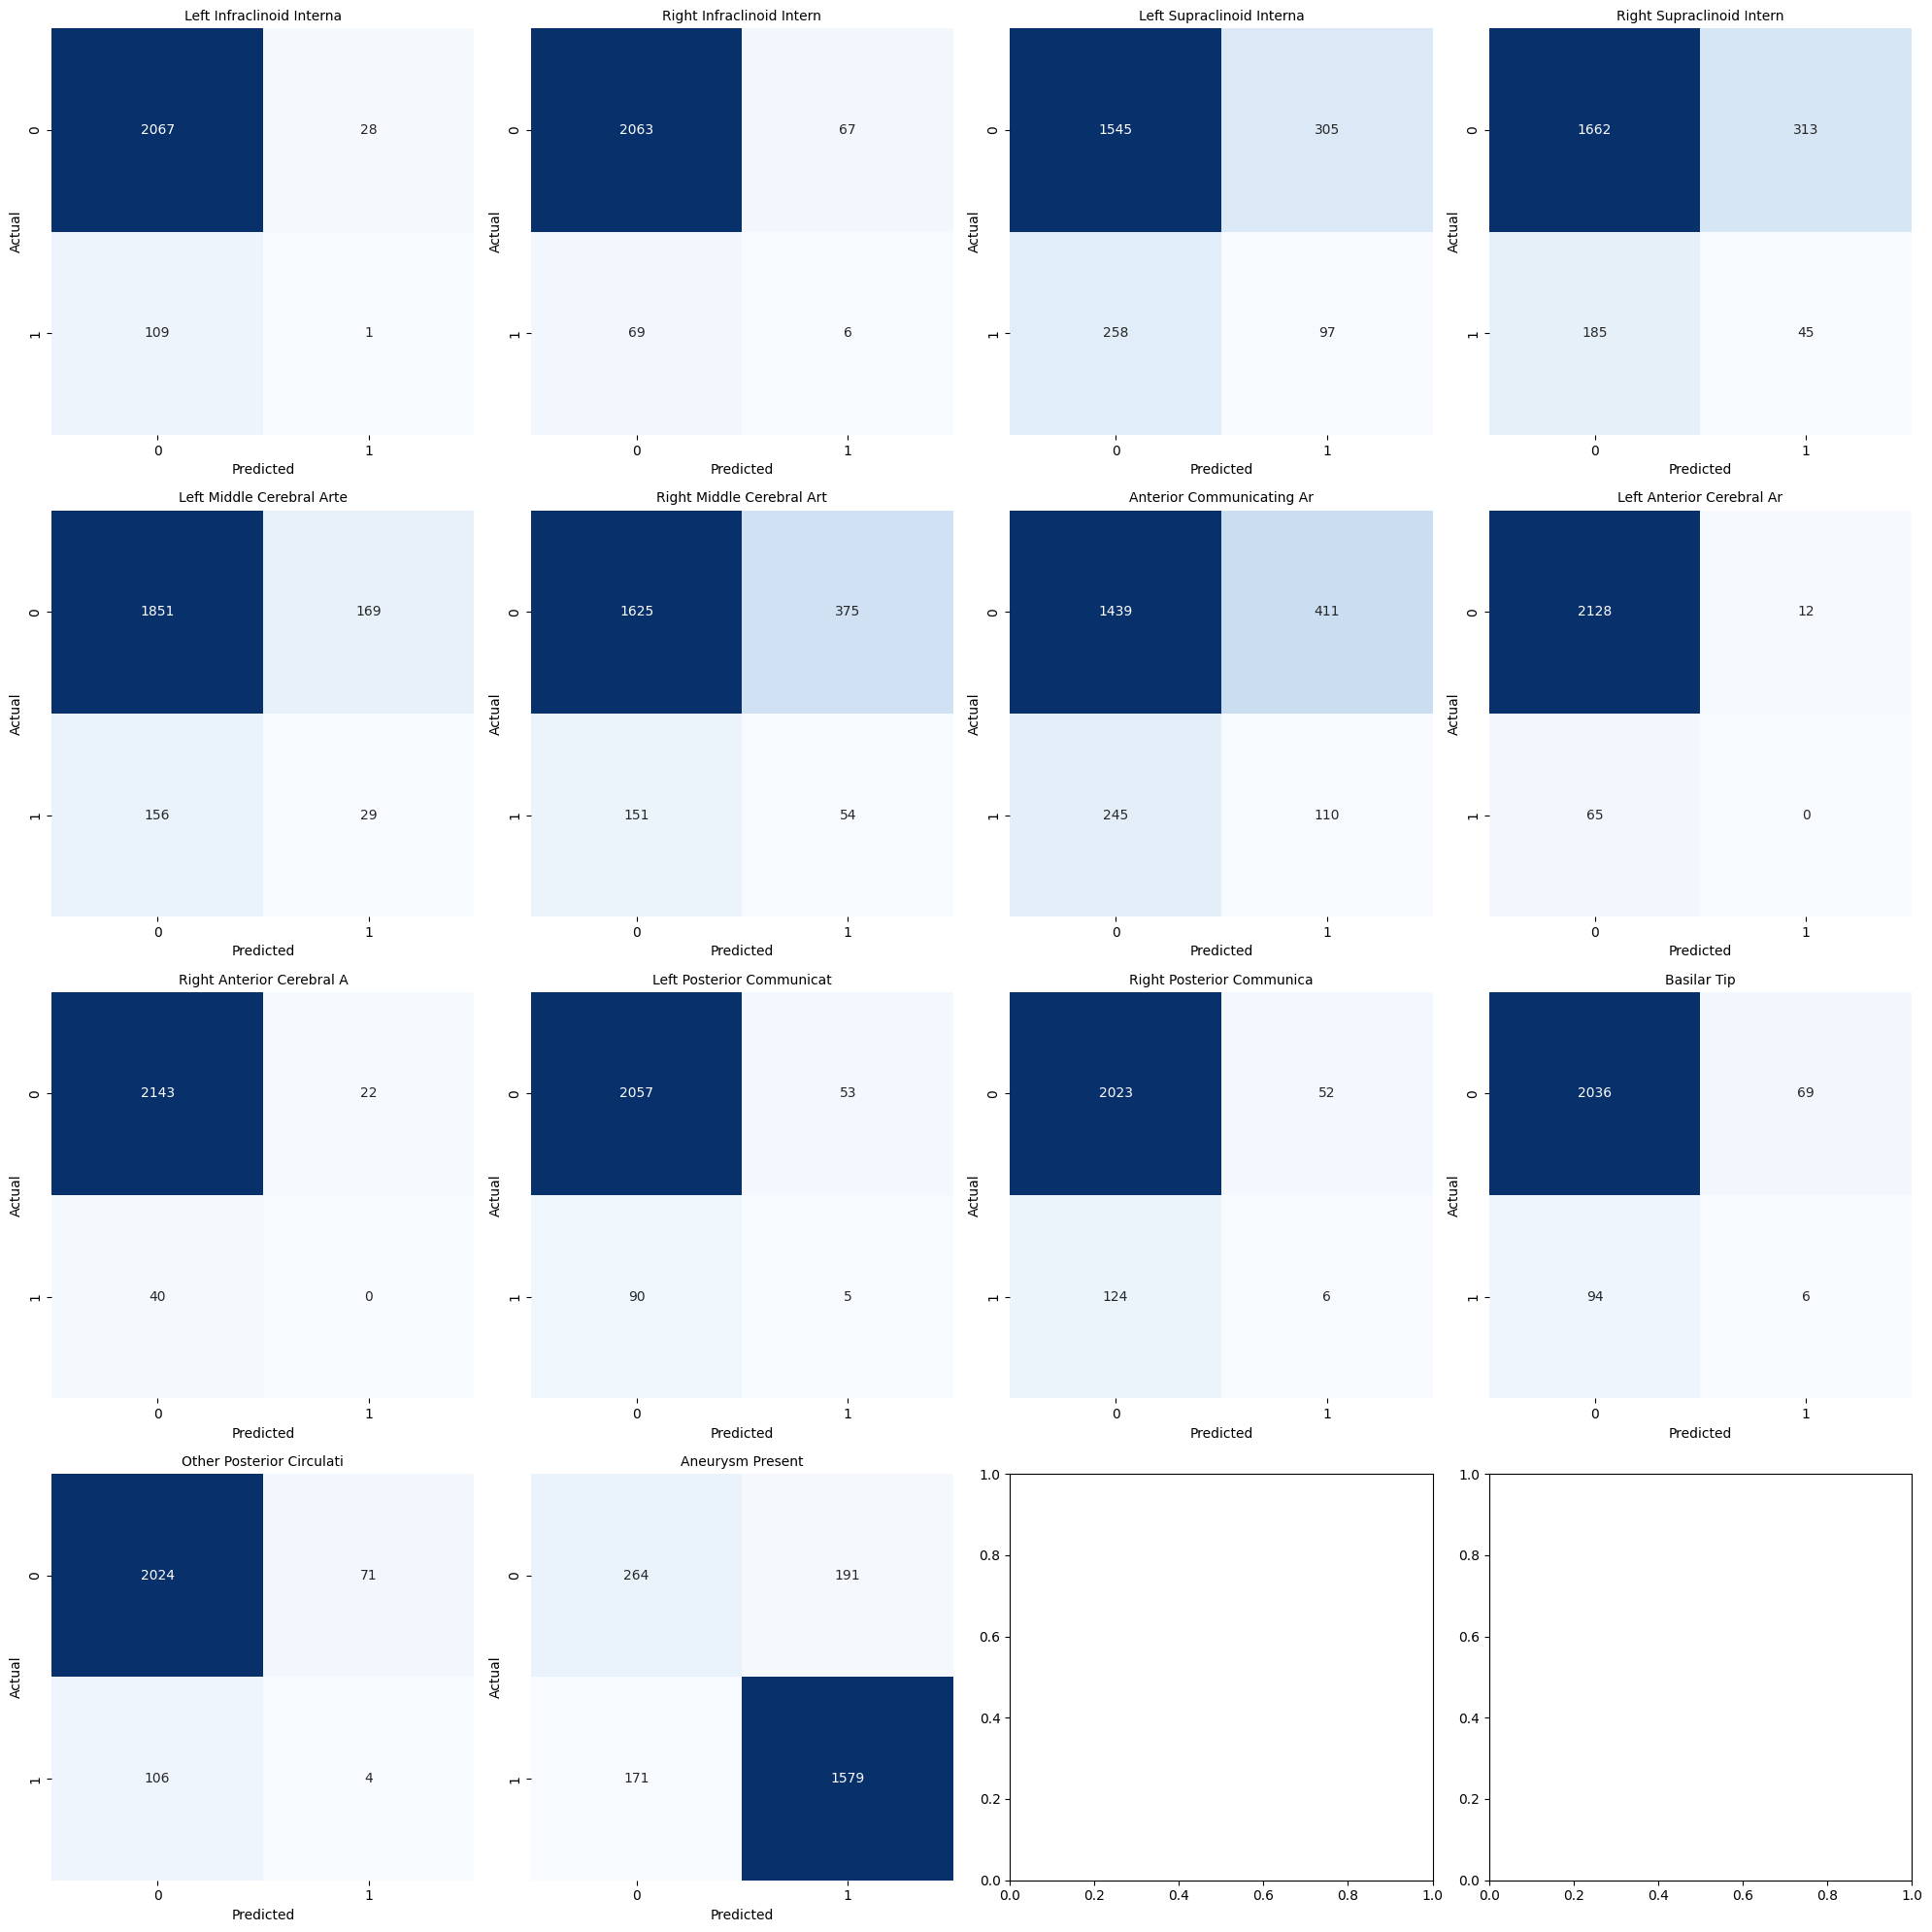

In [6]:
def plot_confusion_grid(model, loader, threshold=0.5):
    model.eval()
    y_true, y_probs = [], []
    
    with torch.no_grad():
        for x, y in tqdm(loader):
            logits = model(x.to(Config.DEVICE))
            y_true.append(y.cpu().numpy())
            y_probs.append(torch.sigmoid(logits).cpu().numpy())
            
    y_true = np.concatenate(y_true)
    y_preds = (np.concatenate(y_probs) > threshold).astype(int)
    
    # Get 14 separate confusion matrices
    mcm = multilabel_confusion_matrix(y_true, y_preds)
    
    # Plotting Grid
    cols = 4
    rows = (len(Config.LABEL_COLS) // cols) + 1
    fig, axes = plt.subplots(rows, cols, figsize=(20, 20))
    axes = axes.flatten()
    
    for i, label in enumerate(Config.LABEL_COLS):
        cm = mcm[i]
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
        axes[i].set_title(label[:25], fontsize=10)
        axes[i].set_ylabel('Actual')
        axes[i].set_xlabel('Predicted')
        
    plt.tight_layout()
    plt.show()

if model: plot_confusion_grid(model, val_loader)

In [7]:
class AneurysmPredictor:
    def __init__(self, checkpoint_path, device='cuda'):
        self.device = device
        print(f"Loading Deployment Model from {checkpoint_path}...")
        
        # 1. Load Metadata
        ckpt = torch.load(checkpoint_path, map_location=device)
        self.labels = ckpt['labels']
        self.cfg = ckpt['config']
        
        # 2. Rebuild Model
        self.model = timm.create_model(self.cfg['model_name'], pretrained=False, in_chans=3, num_classes=0)
        
        # Rebuild Head
        if hasattr(self.model, 'num_features'): dim = self.model.num_features
        else: dim = self.model.embed_dim
            
        self.head = nn.Sequential(
            nn.LayerNorm(dim), nn.Dropout(0.3), nn.Linear(dim, len(self.labels))
        )
        
        # 3. Load Weights
        # We need to reconstruct the full state dict logic
        full_model = nn.Sequential(self.model, self.head)
        
        # Handle state dict key matching (removing 'backbone.' prefix if saved that way)
        state_dict = {k.replace('backbone.', '0.').replace('head.', '1.'): v for k, v in ckpt['state_dict'].items()}
        full_model.load_state_dict(state_dict)
        
        self.model = full_model.to(device).eval()
        print("✅ Model Loaded Successfully.")

    def preprocess(self, path):
        # Same preprocessing as training
        try:
            ds = pydicom.dcmread(path, stop_before_pixels=False)
            img = ds.pixel_array.astype(np.float32)
            center, width = 100, 200
            img = np.clip(img, center - width/2, center + width/2)
            img = (img - (center - width/2)) / width
            return cv2.resize(img, self.cfg['img_size'])
        except: return np.zeros(self.cfg['img_size'])

    def predict(self, dcm_path):
        # 1. Simulate 2.5D Stack (Replicating center slice for simplicity in demo)
        # In real app, you would load dcm_path and its neighbors
        img = self.preprocess(dcm_path)
        stack = np.stack([img, img, img], axis=0) # [3, 224, 224]
        tensor = torch.tensor(stack, dtype=torch.float32).unsqueeze(0).to(self.device)
        
        with torch.no_grad():
            probs = torch.sigmoid(self.model(tensor)).cpu().numpy()[0]
            
        return dict(zip(self.labels, probs))

# --- EXAMPLE USAGE ---
predictor = AneurysmPredictor(Config.SAVE_PATH)
result = predictor.predict("/path/to/test/image.dcm")
print(result)

Loading Deployment Model from best_rsna_swin_model.pth...
✅ Model Loaded Successfully.
{'Left Infraclinoid Internal Carotid Artery': 0.12678681, 'Right Infraclinoid Internal Carotid Artery': 0.10597679, 'Left Supraclinoid Internal Carotid Artery': 0.5017507, 'Right Supraclinoid Internal Carotid Artery': 0.35951796, 'Left Middle Cerebral Artery': 0.44118175, 'Right Middle Cerebral Artery': 0.41072887, 'Anterior Communicating Artery': 0.6912944, 'Left Anterior Cerebral Artery': 0.05951796, 'Right Anterior Cerebral Artery': 0.17110556, 'Left Posterior Communicating Artery': 0.17749307, 'Right Posterior Communicating Artery': 0.31399724, 'Basilar Tip': 0.46081266, 'Other Posterior Circulation': 0.32927635, 'Aneurysm Present': 0.99853647}


📖 Reading the story of your model (Running Inference)...


Reading: 100%|██████████| 138/138 [00:50<00:00,  2.74it/s]



REPORT: MODEL DIAGNOSTIC STORY (Threshold: 0.5)

CHAPTER 1: THE SCREENING CAPABILITY
-----------------------------------
We asked the model: 'Is this patient sick?'
• It caught 1579 confirmed aneurysms.
• It missed 171 aneurysms.
• It raised 191 false alarms.

>> KEY METRIC: SENSITIVITY (RECALL) = 90.2%
   ✅ VERDICT: EXCELLENT. This model is a safe screening tool.
      It rarely lets a sick patient pass through undetected.

>> SECONDARY: SPECIFICITY = 58.0%
   NOTE: The model is 'Paranoid'. It flags many healthy people as sick.
         This is acceptable for screening, but increases doctor workload.


CHAPTER 2: THE ANATOMICAL DETAILS
-----------------------------------
We asked the model: 'WHERE is the aneurysm?'

✅ The model is starting to understand these locations:
   - Right Infraclinoid Internal Carotid Artery (6 caught)
   - Left Supraclinoid Internal Carotid Artery (97 caught)
   - Right Supraclinoid Internal Carotid Artery (45 caught)
   - Left Middle Cerebral Artery (29 ca

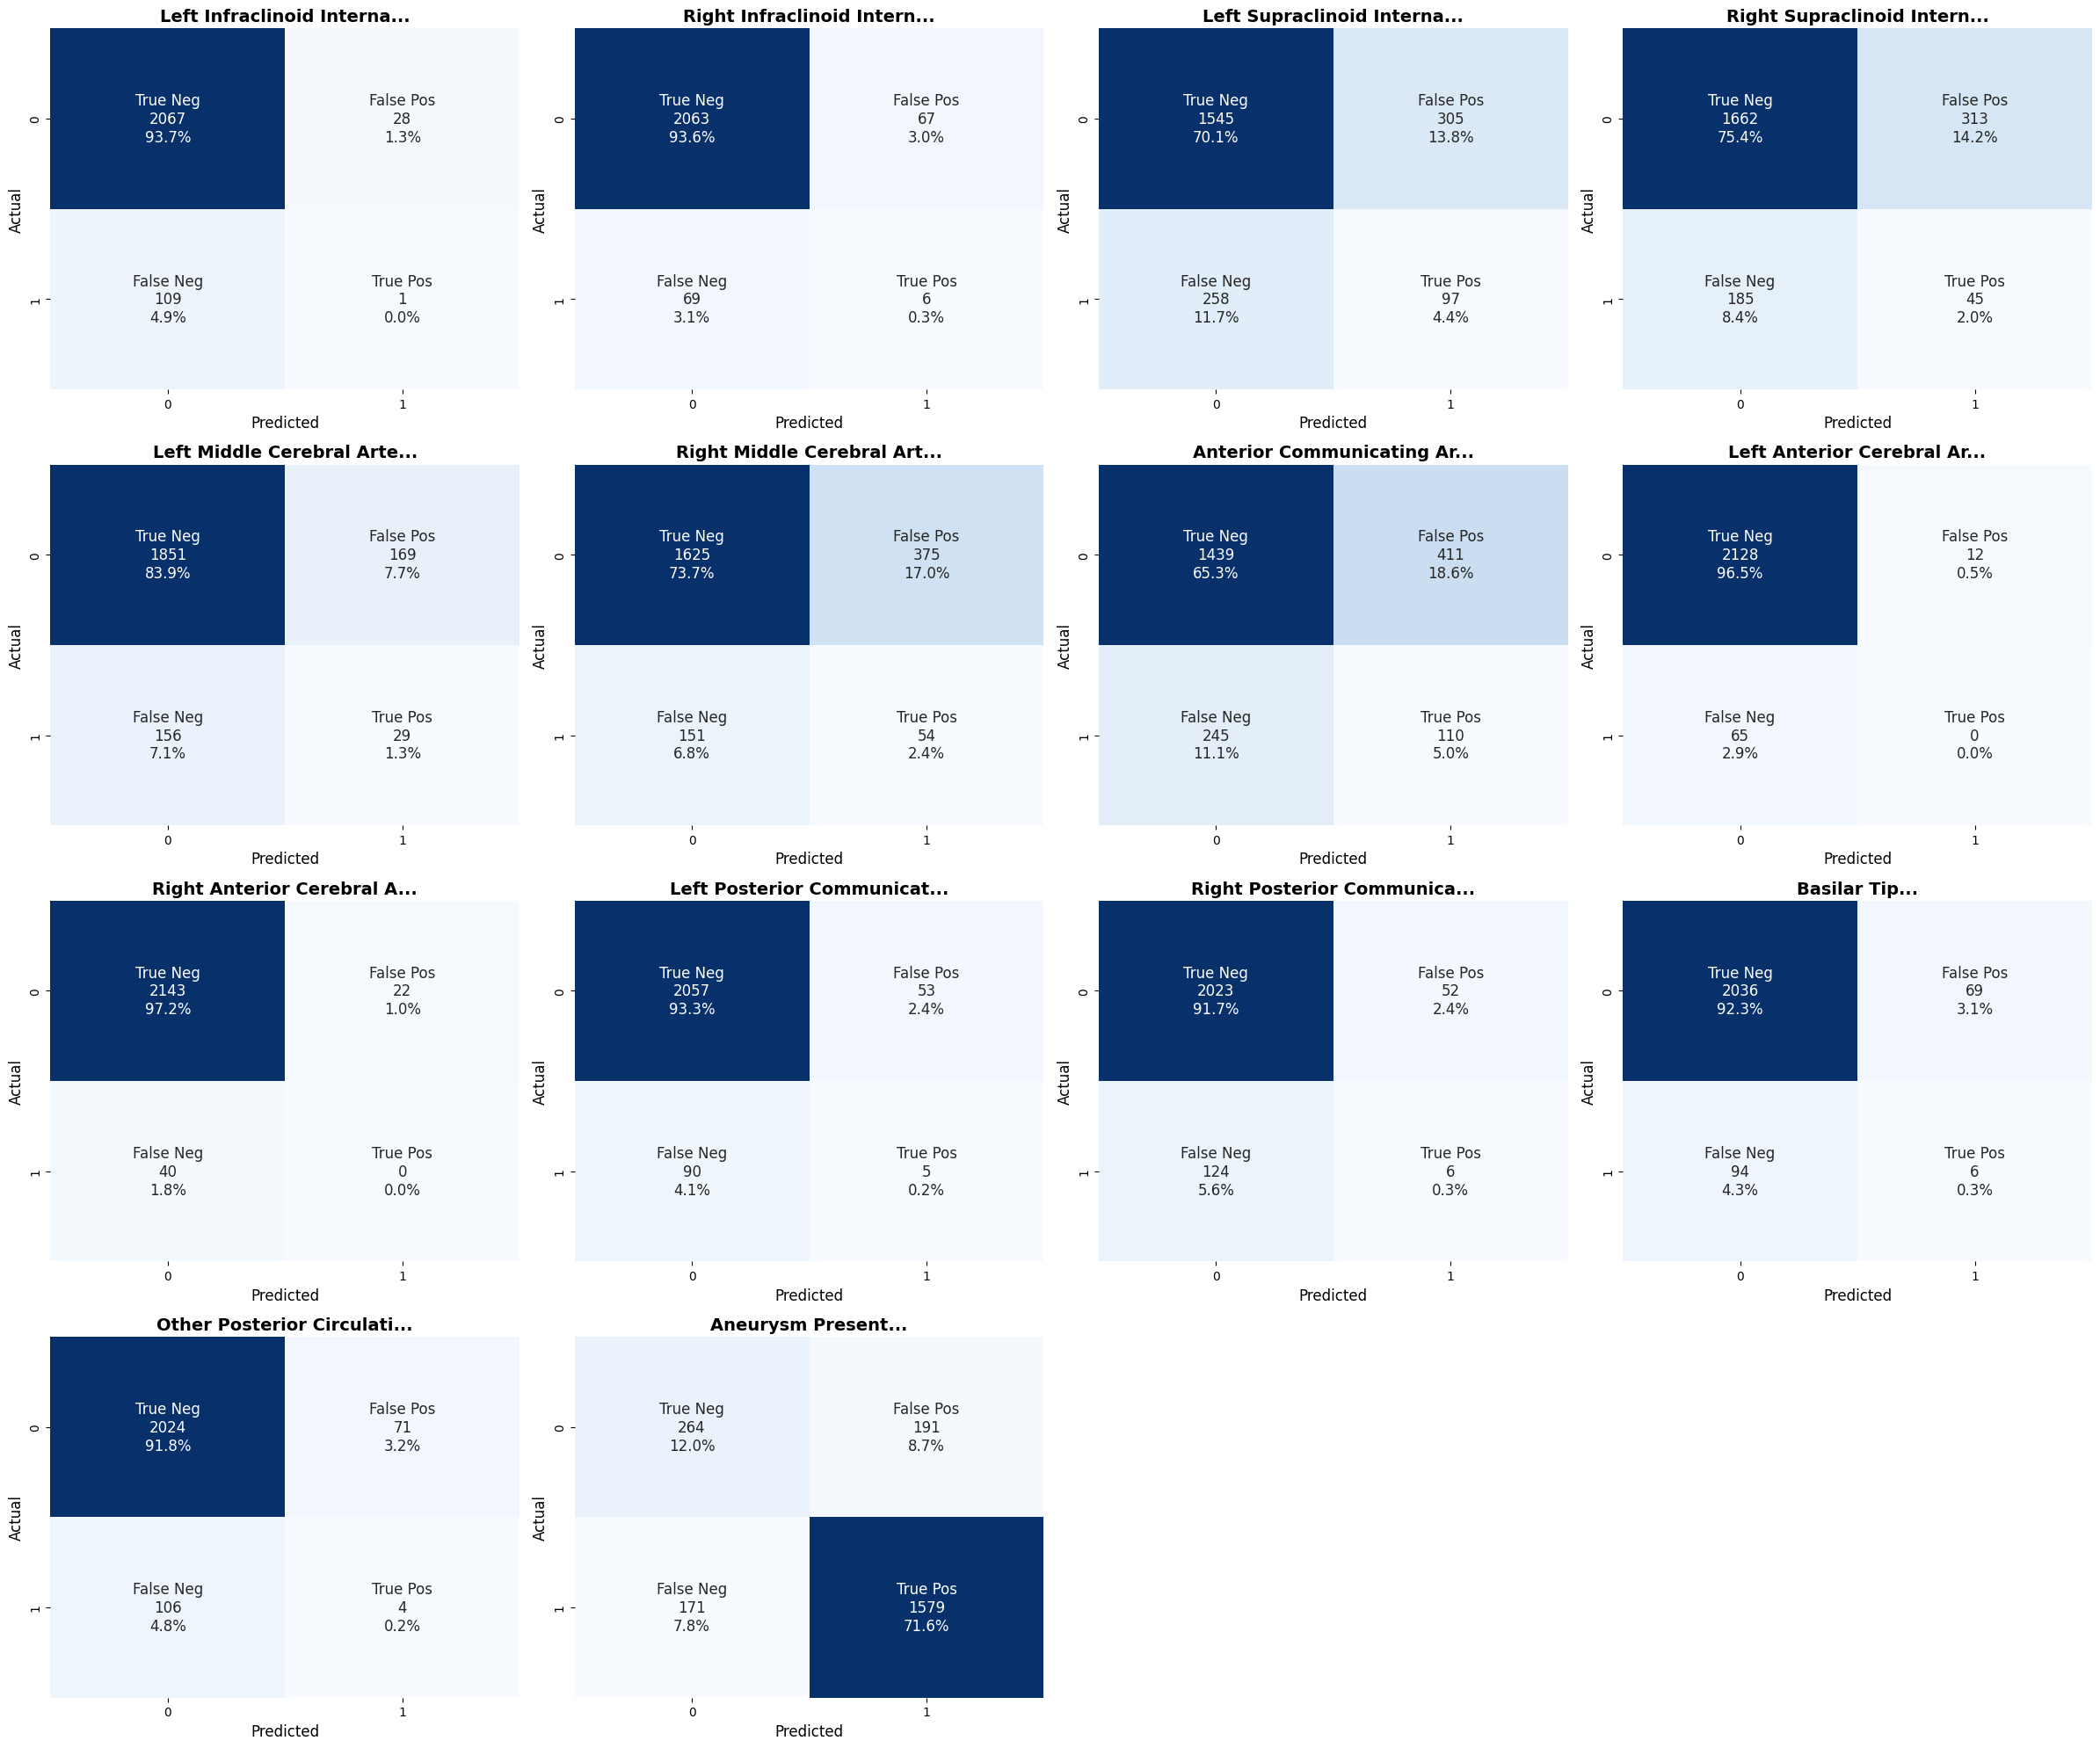

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import multilabel_confusion_matrix, classification_report

def tell_model_story(model, loader, config, threshold=0.5):
    """
    Runs inference, generates a massive confusion matrix grid, 
    and prints a narrative story about the model's performance.
    """
    model.eval()
    y_true_list = []
    y_prob_list = []
    
    print("📖 Reading the story of your model (Running Inference)...")
    with torch.no_grad():
        for x, y in tqdm(loader, desc="Reading"):
            logits = model(x.to(config.DEVICE))
            probs = torch.sigmoid(logits)
            y_true_list.append(y.cpu().numpy())
            y_prob_list.append(probs.cpu().numpy())
            
    y_true = np.concatenate(y_true_list)
    y_probs = np.concatenate(y_prob_list)
    y_preds = (y_probs > threshold).astype(int)
    
    # ==============================================================
    # PART 1: THE NARRATIVE STORY
    # ==============================================================
    labels = config.LABEL_COLS
    
    # Find the main "Aneurysm Present" column
    try:
        global_idx = labels.index('Aneurysm Present')
    except:
        global_idx = -1 # Default to last if not found
        
    print("\n" + "="*60)
    print(f"REPORT: MODEL DIAGNOSTIC STORY (Threshold: {threshold})")
    print("="*60)
    
    # --- Chapter 1: The Screening Performance ---
    mcm = multilabel_confusion_matrix(y_true, y_preds)
    
    # Analyze Global Label (Aneurysm Present)
    cm_global = mcm[global_idx]
    tn, fp, fn, tp = cm_global.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    print(f"\nCHAPTER 1: THE SCREENING CAPABILITY")
    print(f"-----------------------------------")
    print(f"We asked the model: 'Is this patient sick?'")
    print(f"• It caught {tp} confirmed aneurysms.")
    print(f"• It missed {fn} aneurysms.")
    print(f"• It raised {fp} false alarms.")
    
    print(f"\n>> KEY METRIC: SENSITIVITY (RECALL) = {sensitivity:.1%}")
    if sensitivity > 0.85:
        print("   ✅ VERDICT: EXCELLENT. This model is a safe screening tool.")
        print("      It rarely lets a sick patient pass through undetected.")
    elif sensitivity > 0.70:
        print("   ⚠️ VERDICT: DECENT. It catches most cases, but needs supervision.")
    else:
        print("   ❌ VERDICT: DANGEROUS. It misses too many positive cases.")
        
    print(f"\n>> SECONDARY: SPECIFICITY = {specificity:.1%}")
    if specificity < 0.60:
        print("   NOTE: The model is 'Paranoid'. It flags many healthy people as sick.")
        print("         This is acceptable for screening, but increases doctor workload.")
        
    # --- Chapter 2: The Localization Struggle ---
    print(f"\n\nCHAPTER 2: THE ANATOMICAL DETAILS")
    print(f"-----------------------------------")
    print(f"We asked the model: 'WHERE is the aneurysm?'")
    
    loc_success = []
    loc_fail = []
    
    for i, label in enumerate(labels):
        if i == global_idx: continue
        cm = mcm[i]
        _tn, _fp, _fn, _tp = cm.ravel()
        if _tp > 5: # If it caught at least 5 correctly
            loc_success.append(f"{label} ({_tp} caught)")
        else:
            loc_fail.append(label)
            
    if loc_success:
        print(f"\n✅ The model is starting to understand these locations:")
        for s in loc_success: print(f"   - {s}")
    else:
        print(f"\n❌ The model is currently 'Location Blind'.")
        print("   It detects the disease generally, but cannot pinpoint the artery.")
        print("   (Reason: Input resolution 224x224 is likely too low for tiny arteries).")

    # ==============================================================
    # PART 2: THE BIG CONFUSION MATRIX
    # ==============================================================
    print(f"\n\nCHAPTER 3: VISUAL EVIDENCE (The Big Matrix)")
    print(f"-----------------------------------")
    
    cols = 4
    rows = (len(labels) // cols) + 1
    fig, axes = plt.subplots(rows, cols, figsize=(24, rows * 5))
    axes = axes.flatten()
    
    for i, label in enumerate(labels):
        cm = mcm[i]
        
        # Fancy annotations
        group_names = ['True Neg','False Pos','False Neg','True Pos']
        group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
        group_percentages = ["{0:.1%}".format(value) for value in cm.flatten()/np.sum(cm)]
        
        # Color logic: Green for good detection (TP), Red for danger (FN)
        # We use standard Blues, but you look at bottom-right (TP) and bottom-left (FN)
        labels_plot = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
        labels_plot = np.asarray(labels_plot).reshape(2,2)
        
        sns.heatmap(cm, annot=labels_plot, fmt='', cmap='Blues', ax=axes[i], cbar=False, annot_kws={"size": 12})
        axes[i].set_title(f"{label[:25]}...", fontsize=14, fontweight='bold')
        axes[i].set_ylabel('Actual', fontsize=12)
        axes[i].set_xlabel('Predicted', fontsize=12)
        
        # Highlight the "Aneurysm Present" box
        if i == global_idx:
            for spine in axes[i].spines.values():
                spine.set_edgecolor('red')
                spine.set_linewidth(3)
                
    # Hide empty subplots
    for i in range(len(labels), len(axes)):
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.show()

# =========================================
# RUN THE STORYTELLER
# =========================================
# Pass your trained model and validation loader
tell_model_story(model, val_loader, Config, threshold=0.5)